<center>

$\Huge \textbf{Universidad Nacional Autónoma de México}$  
$\Huge \textbf{Facultad de Ciencias}$  
<p align="center">
  <img src="https://www.icat.unam.mx/wp-content/uploads/2021/11/Copia-de-LogoUNAM.-Azul.-Fondo-transparente.png" alt="UNAM" width="200"/>
</p>

<hr style="height:3px; background-color:#0B6E4F; border:none;"/>


$\LARGE \textbf{Inteligencia Artificial}$  

$\Large \textit{Laboratorio 3.3}$  


\begin{array}{rl}
\textbf{Docente:} & Dra. Jessica Sarahi Méndez Rincón \\[6pt]
\textbf{Ayudante de laboratorio:} & Diego Eduardo Peña Villegas \\[6pt]
\textbf{Alumna:} & Marisol Luna Méndez \\[6pt]
\textbf{Fecha de realización:} & 25/02/2026
\end{array}

</center>

# Las cadenas de Markov
Son un modelo que describe una secuencia de eventos donde la probabilidad de un evento depende solo del evento inmediatamente anterior en la secuencia.


Definimos una matriz de transición para un ejemplo de cadena de Markov
En este caso, es una cadena de Markov simple con dos estados: A y B
La matriz de transición representa las probabilidades de pasar de un estado a otro
Por ejemplo, P(A|A) = 0.7 significa que hay un 70% de probabilidad de permanecer en el estado A si ya estamos en A.


In [3]:
import random

In [2]:
matriz_transicion = {
    'A': {'A': 0.7, 'B': 0.3},
    'B': {'A': 0.4, 'B': 0.6}
}


In [6]:
# Estado inicial
estado_actual = 'A'

#Número de pasos o transiciones
num_pasos = 10

#Ejecutamso la cadena de Markov
for paso in range(num_pasos):
    print(f'Paso {paso +1}: Estamos en el estado {estado_actual}')

    #Usamos la matriz de transicion para decidir el proximo estado
    probabilidades = matriz_transicion[estado_actual]
    estados_posibles = list(probabilidades.keys())
    estado_actual = random.choices(estados_posibles, weights = probabilidades.values())[0]

print(f'Finalmente, estamos en el estado {estado_actual}')

Paso 1: Estamos en el estado A
Paso 2: Estamos en el estado A
Paso 3: Estamos en el estado A
Paso 4: Estamos en el estado A
Paso 5: Estamos en el estado A
Paso 6: Estamos en el estado B
Paso 7: Estamos en el estado B
Paso 8: Estamos en el estado B
Paso 9: Estamos en el estado B
Paso 10: Estamos en el estado A
Finalmente, estamos en el estado A


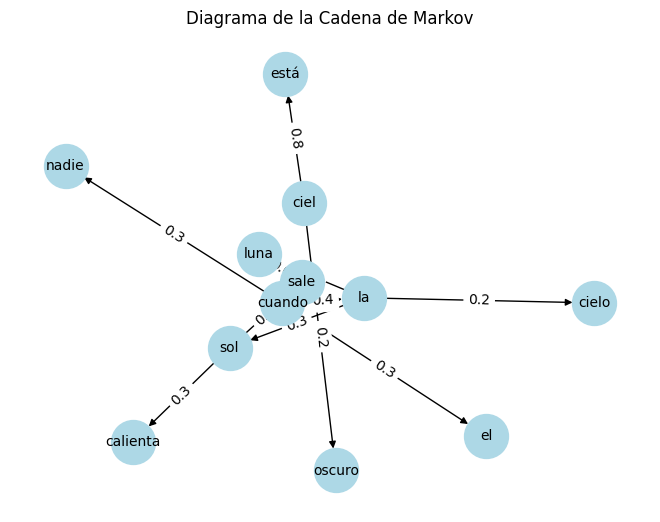

In [11]:
import networkx as nx
import matplotlib.pyplot as plt

#Definimos una matriz de transición para la cedana de MArkov
matriz_transicion = {
    'la':{'luna':0.5,'sol':0.3,'cielo':0.2},
    'luna':{'sale':0.6},
    'sale':{'cuando':1.0},
    'sol':{'sale':0.7, 'calienta':0.3},
    'ciel':{'está':0.8,'oscuro':0.2},
    'cuando':{'la':0.4,'el':0.3,'nadie':0.3}
}

#Crear un objeto de gráfico dirigido
G = nx.DiGraph()

#Agregar nodos al gráfico (estados)
for estado in matriz_transicion:
    G.add_node(estado)

#Agregar arcos ponderados al gráfico (transiciones)
for estado, transiciones in matriz_transicion.items():
  for siguiente_estado, probabilidad in transiciones.items():
    G.add_edge(estado, siguiente_estado, weight = probabilidad)

#Dibujar el gráfico
pos =nx.spring_layout(G, seed=42) #Colocación de nodos
labels = nx.get_edge_attributes(G, 'weight')

nx.draw(G, pos, with_labels=True, node_size = 1000, node_color='lightblue', font_size=10)
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
plt.title('Diagrama de la Cadena de Markov')
plt.show()

# 1. Modelo del clima usando numpy

Aquí ya trabajamos con matrices de transición, que es la forma formal de las cadenas de Markov.

In [13]:
import random

#Definición manual del modelo
transiciones ={
    "Soleado":[("Soleado",0.8),("Nublado",0.15),("Lluvioso",0.05)],
    "Nublado":[("Soleado",0.2),("Nublado",0.5),("Lluvioso",0.3)],
    "Lluvioso":[("Soleado",0.2),("Nublado",0.2),("Lluvioso",0.6)]
}

def siguiente_estado(estado_actual):
    opciones=transiciones[estado_actual]
    r = random.random() #número entre 0 y 1
    acumulado = 0
    for estado, prob in opciones:
        acumulado +=prob
        if r <= acumulado:
            return estado


def simular_clima(estado_inicial, dias):
    estado = estado_inicial
    historial = [estado]

    for _ in range(dias):
        estado = siguiente_estado(estado)
        historial.append(estado)

    return historial

In [14]:
#Ejemplo
resultado = simular_clima ("Soleado",10)
print("simulación del clima:")
print(resultado)

simulación del clima:
['Soleado', 'Soleado', 'Soleado', 'Soleado', 'Soleado', 'Soleado', 'Soleado', 'Soleado', 'Soleado', 'Soleado', 'Soleado']


# Desde cero  

<hr/>
<footer style="text-align:center; font-size:12px; color:gray;">
© 2026 UNAM Facultado de Ciencias – Todos los derechos reservados

</footer>